## 2. Import Required Libraries

In [4]:
# EDA tools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(10)
import warnings
warnings.filterwarnings("ignore")

#Single model classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Ensemble classifications models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics._scorer import _SCORERS
from sklearn.metrics import (accuracy_score,confusion_matrix, classification_report, roc_auc_score,
f1_score, recall_score, precision_score)
import time

# Imbalance, Hyperparameter tunning and pipelines
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

### 2.1 Helper Functions

In [77]:
def distbox_plot(data):
    '''Function to plot a seaborn distribution plot 
        with a box plot on top.
        Reference: https://python-graph-gallery.com/24-histogram-with-a-boxplot-on-top-seaborn/'''
    # Cut the window in 2 parts
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(14,4),gridspec_kw={"height_ratios": (.15, .85)})
    # Add a graph in each part
    sns.boxplot(data, ax=ax_box)
    sns.distplot(data, ax=ax_hist)
    # Remove x axis name for the boxplot
    ax_box.set(xlabel='')
    #Print describtive statistics
    print(data.describe())

def baseline_models(data=[], verbose=False):
    #List of models to be used
    models=[DecisionTreeClassifier(),LogisticRegression(),
            RandomForestClassifier(),GradientBoostingClassifier()]
    #Create training and testing data sets depending on wheather or not they have been generated previously.
    if len(data)== 2:
        X_train, X_test, y_train, y_test = train_test_split(data[0],data[1],random_state=123)
    else:
        X_train, X_test, y_train, y_test = data[0],data[1],data[2],data[3]
    #Instantiate lists to store each of the models results
    accuracy = []
    f1 = []
    auc = []
    recall = []
    precision = []
    #Run thorugh each of the models to get their performance metrics
    for model in models:
        clf = model
        clf.fit(X_train, y_train)
        test_preds = clf.predict(X_test)
        f1.append(f1_score(y_test, test_preds))
        accuracy.append(accuracy_score(y_test, test_preds))
        auc.append(roc_auc_score(y_test, test_preds))
        recall.append(recall_score(y_test, test_preds))
        precision.append(precision_score(y_test, test_preds))
        #Print the model and its report
        if verbose:
            print('Classification Model: ',model,'\n')
            print(classification_report(y_test, test_preds),'\n')
    #store results in dataframe
    results = pd.DataFrame([f1,auc, accuracy, precision,recall],
                      index= ['f1','roc_auc','accuracy','precision','recall',],
                           columns=['DecisionTree','LogisticRegression','RandomForest','Gradient Boosting'])
                           #columns=['LogisticRegression','RandomForest','Gradient Boosting'])
    #Change orientation of the dataframe
    return results.transpose()

def plot_feat_importance(clf,index):
    '''Plot the 0 most important features for a classifier model in a bar chart
    according to importance'''
    feat_importances = pd.DataFrame(clf.feature_importances_, index=index, columns=['Score'])
    feat_importances = feat_importances.sort_values(by='Score',ascending=True).tail(10)
    feat_importances.plot(kind='barh', title='Top 10 Important Features',legend=False)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.show();
    
def heatmap(data,figsize=(8,8), annot=False):
    #plot heatmap to find multicollinearity
    plt.figure(figsize=figsize)
    cmap = sns.diverging_palette(220, 20, sep=20, as_cmap=True)
    sns.heatmap(data.corr(),vmin=-0.75,vmax=0.75,center=0, cmap=cmap,annot=annot);

def grid_pipe(pipedict, hyperdict, scoring='accuracy', display=True):
    model_scores=[]
    fitted_models={}
    for name, pipeline in pipedict.items():
    # Construct grid search
        model = GridSearchCV(estimator=pipeline,
                             param_grid=hyperdict[name],
                             scoring=scoring,
                             cv=5, verbose=2, n_jobs=-1, return_train_score = True)

        # Fit using grid search
        start = time.time()
        model.fit(X_trainres, y_trainres)
        end = time.time()
        #Append socres and time
        model_scores.append((name,model.best_score_,end-start))
        #Append model
        fitted_models[name]=model
        if display:
            #Print when the model has been fitted
            print(f'The {name} model has been fitted.')
            # Best accuracy
            print('Best accuracy: %.3f' % model.best_score_)
            # Best params
            print('Best params:\n', model.best_params_,'\n')
    
    return model_scores, fitted_models

In [6]:
  
# -*- coding: utf-8 -*-
"""
plot a pretty confusion matrix with seaborn
Created on Mon Jun 25 14:17:37 2018
@author: Wagner Cipriano - wagnerbhbr - gmail - CEFETMG / MMC
REFerences:
  https://www.mathworks.com/help/nnet/ref/plotconfusion.html
  https://stackoverflow.com/questions/28200786/how-to-plot-scikit-learn-classification-report
  https://stackoverflow.com/questions/5821125/how-to-plot-confusion-matrix-with-string-axis-rather-than-integer-in-python
  https://www.programcreek.com/python/example/96197/seaborn.heatmap
  https://stackoverflow.com/questions/19233771/sklearn-plot-confusion-matrix-with-labels/31720054
  http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py
"""

#imports
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.collections import QuadMesh
import seaborn as sn


def get_new_fig(fn, figsize=[9,9]):
    """ Init graphics """
    fig1 = plt.figure(fn, figsize)
    ax1 = fig1.gca()   #Get Current Axis
    ax1.cla() # clear existing plot
    return fig1, ax1
#

def configcell_text_and_colors(array_df, lin, col, oText, facecolors, posi, fz, fmt, show_null_values=0):
    """
      config cell text and colors
      and return text elements to add and to dell
      @TODO: use fmt
    """
    text_add = []; text_del = [];
    cell_val = array_df[lin][col]
    tot_all = array_df[-1][-1]
    per = (float(cell_val) / tot_all) * 100
    curr_column = array_df[:,col]
    ccl = len(curr_column)

    #last line  and/or last column
    if(col == (ccl - 1)) or (lin == (ccl - 1)):
        #tots and percents
        if(cell_val != 0):
            if(col == ccl - 1) and (lin == ccl - 1):
                tot_rig = 0
                for i in range(array_df.shape[0] - 1):
                    tot_rig += array_df[i][i]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(col == ccl - 1):
                tot_rig = array_df[lin][lin]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(lin == ccl - 1):
                tot_rig = array_df[col][col]
                per_ok = (float(tot_rig) / cell_val) * 100
            per_err = 100 - per_ok
        else:
            per_ok = per_err = 0

        per_ok_s = ['%.2f%%'%(per_ok), '100%'] [per_ok == 100]

        #text to DEL
        text_del.append(oText)

        #text to ADD
        font_prop = fm.FontProperties(weight='bold', size=fz)
        text_kwargs = dict(color='k', ha="center", va="center", gid='sum', fontproperties=font_prop)
        lis_txt = ['%d'%(cell_val), per_ok_s, '%.2f%%'%(per_err)]
        lis_kwa = [text_kwargs]
        dic = text_kwargs.copy(); dic['color'] = 'g'; lis_kwa.append(dic);
        dic = text_kwargs.copy(); dic['color'] = 'r'; lis_kwa.append(dic);
        lis_pos = [(oText._x, oText._y-0.3), (oText._x, oText._y), (oText._x, oText._y+0.3)]
        for i in range(len(lis_txt)):
            newText = dict(x=lis_pos[i][0], y=lis_pos[i][1], text=lis_txt[i], kw=lis_kwa[i])
            #print 'lin: %s, col: %s, newText: %s' %(lin, col, newText)
            text_add.append(newText)
        #print '\n'

        #set background color for sum cells (last line and last column)
        carr = [0.27, 0.30, 0.27, .1]
        if(col == ccl - 1) and (lin == ccl - 1):
            carr = [0.17, 0.20, 0.17, .1]
        facecolors[posi] = carr

    else:
        if(per > 0):
            txt = '%s\n%.2f%%' %(cell_val, per)
        else:
            if(show_null_values == 0):
                txt = ''
            elif(show_null_values == 1):
                txt = '0'
            else:
                txt = '0\n0.0%'
        oText.set_text(txt)

        #main diagonal
        if(col == lin):
            #set color of the textin the diagonal to white
            oText.set_color('w')
            # set background color in the diagonal to blue
            facecolors[posi] = [0.35, 0.8, 0.55, 1.0]
        else:
            oText.set_color('r')

    return text_add, text_del
#

def insert_totals(df_cm):
    """ insert total column and line (the last ones) """
    sum_col = []
    for c in df_cm.columns:
        sum_col.append( df_cm[c].sum() )
    sum_lin = []
    for item_line in df_cm.iterrows():
        sum_lin.append( item_line[1].sum() )
    df_cm['sum_lin'] = sum_lin
    sum_col.append(np.sum(sum_lin))
    df_cm.loc['sum_col'] = sum_col
    #print ('\ndf_cm:\n', df_cm, '\n\b\n')
#

def pretty_plot_confusion_matrix(df_cm, annot=True, cmap="Oranges", fmt='.2f', fz=11,
      lw=0.5, cbar=False, figsize=[8,8], show_null_values=0, pred_val_axis='y'):
    """
      print conf matrix with default layout (like matlab)
      params:
        df_cm          dataframe (pandas) without totals
        annot          print text in each cell
        cmap           Oranges,Oranges_r,YlGnBu,Blues,RdBu, ... see:
        fz             fontsize
        lw             linewidth
        pred_val_axis  where to show the prediction values (x or y axis)
                        'col' or 'x': show predicted values in columns (x axis) instead lines
                        'lin' or 'y': show predicted values in lines   (y axis)
    """
    if(pred_val_axis in ('col', 'x')):
        xlbl = 'Predicted'
        ylbl = 'Actual'
    else:
        xlbl = 'Actual'
        ylbl = 'Predicted'
        df_cm = df_cm.T

    # create "Total" column
    insert_totals(df_cm)

    #this is for print allways in the same window
    fig, ax1 = get_new_fig('Conf matrix default', figsize)

    #thanks for seaborn
    ax = sn.heatmap(df_cm, annot=annot, annot_kws={"size": fz}, linewidths=lw, ax=ax1,
                    cbar=cbar, cmap=cmap, linecolor='w', fmt=fmt)

    #set ticklabels rotation
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, fontsize = 10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation = 25, fontsize = 10)

    # Turn off all the ticks
    for t in ax.xaxis.get_major_ticks():
        t.tick1On = False
        t.tick2On = False
    for t in ax.yaxis.get_major_ticks():
        t.tick1On = False
        t.tick2On = False

    #face colors list
    quadmesh = ax.findobj(QuadMesh)[0]
    facecolors = quadmesh.get_facecolors()

    #iter in text elements
    array_df = np.array( df_cm.to_records(index=False).tolist() )
    text_add = []; text_del = [];
    posi = -1 #from left to right, bottom to top.
    for t in ax.collections[0].axes.texts: #ax.texts:
        pos = np.array( t.get_position()) - [0.5,0.5]
        lin = int(pos[1]); col = int(pos[0]);
        posi += 1
        #print ('>>> pos: %s, posi: %s, val: %s, txt: %s' %(pos, posi, array_df[lin][col], t.get_text()))

        #set text
        txt_res = configcell_text_and_colors(array_df, lin, col, t, facecolors, posi, fz, fmt, show_null_values)

        text_add.extend(txt_res[0])
        text_del.extend(txt_res[1])

    #remove the old ones
    for item in text_del:
        item.remove()
    #append the new ones
    for item in text_add:
        ax.text(item['x'], item['y'], item['text'], **item['kw'])

    #titles and legends
    ax.set_title('Confusion matrix')
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)
    plt.tight_layout()  #set layout slim
    plt.show()
#

def plot_confusion_matrix_from_data(y_test, predictions, columns=None, annot=True, cmap="Oranges",
      fmt='.2f', fz=11, lw=0.5, cbar=False, figsize=[8,8], show_null_values=0, pred_val_axis='lin'):
    """
        plot confusion matrix function with y_test (actual values) and predictions (predic),
        whitout a confusion matrix yet
    """
    from sklearn.metrics import confusion_matrix
    from pandas import DataFrame

    #data
    if(not columns):
        #labels axis integer:
        ##columns = range(1, len(np.unique(y_test))+1)
        #labels axis string:
        from string import ascii_uppercase
        columns = ['class %s' %(i) for i in list(ascii_uppercase)[0:len(np.unique(y_test))]]

    confm = confusion_matrix(y_test, predictions)
    df_cm = DataFrame(confm, index=columns, columns=columns)
    pretty_plot_confusion_matrix(df_cm, fz=fz, cmap=cmap, figsize=figsize, show_null_values=show_null_values, pred_val_axis=pred_val_axis)

## 3. Exploratory Data Analysis


In [7]:
#Load the file into a pandas data frame.
data = pd.read_csv("diabetes.csv")
#Get structural information of the data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [11]:
#Visualize first 5 rows of data of the first 12 columns.
data.head().iloc[:,:12]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN


In [12]:
#Visualize first 5 rows of data of the remaining columns.
data.head().iloc[:,12:]

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,41,0,1,0,0,0,250.83,NaN,NaN,1,...,No,No,No,No,No,No,No,No,No,NO
1,59,0,18,0,0,0,276,250.01,255,9,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,11,5,13,2,0,1,648,250,V27,6,...,No,No,No,No,No,No,No,No,Yes,NO
3,44,1,16,0,0,0,8,250.43,403,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,51,0,8,0,0,0,197,157,250,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [14]:
#Look for missing values.
data.isna().any()

encounter_id                False
patient_nbr                 False
race                         True
gender                      False
age                         False
weight                       True
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                   True
medical_specialty            True
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                       True
diag_2                       True
diag_3                       True
number_diagnoses            False
max_glu_serum                True
A1Cresult                    True
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide 

In [16]:
#Do data preprocessing on missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
data = data.drop(columns=cols_to_drop)
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [17]:
# Remove columns with only one unique value
data = data.drop(columns=['citoglipton', 'examide'])
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [19]:
#For the "race" column, which is a categorical feature and already includes an "Other" category, we will assign all missing values to "Other"
data['race'] = data['race'].fillna('Other')

In [20]:
def icd9_to_numeric(icd_code):
    if pd.isna(icd_code) or icd_code == 'Unknown':
        return 0
    code_str = str(icd_code)
    if code_str.startswith('E') or code_str.startswith('V'):
        return 1000
    try:
        # Keep only the integer part before decimal point
        return int(float(code_str))
    except:
        return 0 

# Process three diagnosis features
data['diag_1_numeric'] = data['diag_1'].apply(icd9_to_numeric)
data['diag_2_numeric'] = data['diag_2'].apply(icd9_to_numeric)
data['diag_3_numeric'] = data['diag_3'].apply(icd9_to_numeric)

# Delete diag_1, diag_2, diag_3 columns
data = data.drop(columns=['diag_1', 'diag_2', 'diag_3'])
data.head()

# Rename diag_1_numeric, diag_2_numeric, diag_3_numeric columns to diag_1, diag_2, diag_3
data = data.rename(columns={'diag_1_numeric': 'diag_1', 'diag_2_numeric': 'diag_2', 'diag_3_numeric': 'diag_3'})
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Ch,Yes,>30,276,250,255
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,Yes,NO,648,250,1000
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Ch,Yes,NO,8,250,403
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,No,No,Ch,Yes,NO,197,157,250


In [22]:
data.describe().iloc[:,:12]

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000


In [23]:
data.describe().iloc[:,12:]

,number_diagnoses,diag_1,diag_2,diag_3
count,101766.000000,101766.000000,101766.000000,101766.000000
mean,7.422607,501.629130,451.103060,441.231168
std,1.933600,214.898338,198.686789,219.514279
min,1.000000,0.000000,0.000000,0.000000
25%,6.000000,410.000000,276.000000,274.000000
50%,8.000000,441.000000,427.000000,411.000000
75%,9.000000,599.000000,569.000000,535.000000
max,16.000000,1000.000000,1000.000000,1000.000000


In [24]:
#Get number of unique values for each discrete variable in the dataset.
for col in data.describe().columns:
    if data[col].dtype == int:
        print(f'{col}:', data[col].nunique())

encounter_id: 101766
patient_nbr: 71518
admission_type_id: 8
discharge_disposition_id: 26
admission_source_id: 17
time_in_hospital: 14
num_lab_procedures: 118
num_procedures: 7
num_medications: 75
number_outpatient: 39
number_emergency: 33
number_inpatient: 21
number_diagnoses: 16
diag_1: 666
diag_2: 619
diag_3: 640


In [27]:
#Get value counts for SpecialDay
data.readmitted.value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [28]:
#Get non-numerical features.
non_num_cols = list(set(data.columns) - set(data.describe().columns))
print('Non-numerical features: ',non_num_cols)

Non-numerical features:  ['tolbutamide', 'glyburide', 'acarbose', 'race', 'metformin-rosiglitazone', 'glipizide', 'age', 'insulin', 'repaglinide', 'nateglinide', 'diabetesMed', 'acetohexamide', 'rosiglitazone', 'chlorpropamide', 'glimepiride-pioglitazone', 'pioglitazone', 'tolazamide', 'glimepiride', 'gender', 'glipizide-metformin', 'readmitted', 'troglitazone', 'miglitol', 'glyburide-metformin', 'metformin', 'metformin-pioglitazone', 'change']


In [40]:
#Get numerical features.
num_cols = list(set(data.describe().columns))
print('Numerical features: ', num_cols)

Numerical features:  ['diag_2', 'diag_1', 'discharge_disposition_id', 'admission_source_id', 'admission_type_id', 'num_medications', 'diag_3', 'time_in_hospital', 'num_lab_procedures', 'number_inpatient', 'num_procedures', 'number_outpatient', 'number_diagnoses', 'patient_nbr', 'encounter_id', 'number_emergency']


#### 4.1 One-hot-code categorical features

In [64]:
#Create list with categorical features' names.
data.readmitted[data.readmitted =='>30'] = 2
data.readmitted[data.readmitted =='<30'] = 1
data.readmitted[data.readmitted =='NO'] = 0

target = data.readmitted.copy()
non_num_cols.remove('readmitted')
nonum_feats_names = non_num_cols

#Create list with numerical features' names.
num_cols_names = num_cols

In [65]:
#Assign appropriate data type to categorical variables.
nonum_feats = data[nonum_feats_names].astype('category')
nonum_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   tolbutamide               101766 non-null  category
 1   glyburide                 101766 non-null  category
 2   acarbose                  101766 non-null  category
 3   race                      101766 non-null  category
 4   metformin-rosiglitazone   101766 non-null  category
 5   glipizide                 101766 non-null  category
 6   age                       101766 non-null  category
 7   insulin                   101766 non-null  category
 8   repaglinide               101766 non-null  category
 9   nateglinide               101766 non-null  category
 10  diabetesMed               101766 non-null  category
 11  acetohexamide             101766 non-null  category
 12  rosiglitazone             101766 non-null  category
 13  chlorpropamide            101

In [67]:
#One-hot-code categorical variables and dropping the reference value.
ohc_feats = pd.get_dummies(nonum_feats,drop_first=True)
ohc_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 65 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   tolbutamide_Steady               101766 non-null  bool 
 1   glyburide_No                     101766 non-null  bool 
 2   glyburide_Steady                 101766 non-null  bool 
 3   glyburide_Up                     101766 non-null  bool 
 4   acarbose_No                      101766 non-null  bool 
 5   acarbose_Steady                  101766 non-null  bool 
 6   acarbose_Up                      101766 non-null  bool 
 7   race_Asian                       101766 non-null  bool 
 8   race_Caucasian                   101766 non-null  bool 
 9   race_Hispanic                    101766 non-null  bool 
 10  race_Other                       101766 non-null  bool 
 11  metformin-rosiglitazone_Steady   101766 non-null  bool 
 12  glipizide_No                  



### 4.2 Plain Vanilla Classification Models

The classifiers that I will be testing are:
* Logistic Regression
+ Decision Tree
* Random Forest
* Gradient Boosting

In [79]:
ohc_data = pd.concat([data[num_cols_names], ohc_feats],axis=1)
ohc_data = ohc_data.apply(pd.to_numeric)
target = target.apply(pd.to_numeric)
#results1 = baseline_models(data=[ohc_data,target], verbose=True)


In [82]:
X_train, X_test, y_train, y_test = train_test_split(ohc_data, target, test_size = 0.25, random_state = 42)


In [85]:
from sklearn.utils.validation import column_or_1d
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [86]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.50

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.60      0.59     13675
           1       0.00      0.00      0.00      2849
           2       0.40      0.52      0.45      8918

    accuracy                           0.50     25442
   macro avg       0.33      0.37      0.35     25442
weighted avg       0.45      0.50      0.48     25442



In [89]:
#ordinal_encoder = ce.OrdinalEncoder()
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.60

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.84      0.72     13675
           1       0.47      0.01      0.03      2849
           2       0.52      0.41      0.46      8918

    accuracy                           0.60     25442
   macro avg       0.54      0.42      0.40     25442
weighted avg       0.57      0.60      0.55     25442



The Gradient Boosting Classifier is the best performing so far. Being this a binary classification problem with an imbalanced dataset, I am mostly concerned with the f1 and roc_auc scores. The f1 score is the harmonic mean between precision and recall, while the roc_auc score is the area under the roc curve from the predicted values. It is important to distiguish between both categories since marketing strategies could  be costly if not applied correctly to the users.

In [91]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.60

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.84      0.72     13675
           1       0.49      0.03      0.06      2849
           2       0.53      0.42      0.47      8918

    accuracy                           0.60     25442
   macro avg       0.55      0.43      0.42     25442
weighted avg       0.58      0.60      0.56     25442



In [100]:
#Create a final dataframe with all numerical variables in the first columns.
final_df = pd.concat([ohc_data[num_cols_names],ohc_feats],axis=1)
#Create final train and test sets startified according to the target variable. 
X_train, X_test, y_train, y_test = train_test_split(final_df,target, test_size = 0.30,stratify=target, 
                                                    random_state=123)

In [101]:
'''Scaling the data first fitting it and transforming the training set
to later aply the fit to transform the test set.'''
#Instantiate Satandard Scaler
scaler = StandardScaler()
#Fit transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_train = pd.DataFrame(scaler.fit_transform(X_train[num_cols_names]), 
                                     columns=num_cols_names, index= X_train.index)
#Integrate scaled values to the training set
for col in num_cols_names:
    X_train[col] = scaled_numfeats_train[col]
#Transform the numerical features inthe training dataset to a new dataframe
scaled_numfeats_test = pd.DataFrame(scaler.transform(X_test[num_cols_names]),
                                    columns=num_cols_names, index= X_test.index)
#Integrate scaled values to the test set
for col in num_cols_names:
    X_test[col] = scaled_numfeats_test[col]

In [103]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [104]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.51

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.63      0.64     16459
           1       0.19      0.37      0.25      3407
           2       0.47      0.36      0.41     10664

    accuracy                           0.51     30530
   macro avg       0.44      0.45      0.43     30530
weighted avg       0.54      0.51      0.52     30530



The f1 scores of the baseline models improved by scaling the data. Especifically, gradient boosting saw the greatest performance increase from a little less than 63% to 67%. Now, in an effort to correct the imbalanced dataset I wil perform Synthetic Minority Over-sampling Technique to create synthetic data that helps the model balance the target incidence. 

In [105]:
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.60

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.84      0.72     16459
           1       0.41      0.01      0.03      3407
           2       0.53      0.42      0.47     10664

    accuracy                           0.60     30530
   macro avg       0.52      0.42      0.40     30530
weighted avg       0.57      0.60      0.55     30530



In [106]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.61

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.84      0.72     16459
           1       0.50      0.03      0.06      3407
           2       0.54      0.43      0.48     10664

    accuracy                           0.61     30530
   macro avg       0.56      0.43      0.42     30530
weighted avg       0.59      0.61      0.56     30530



In [108]:
print(len(num_cols_names) + len(non_num_cols))

42


In [113]:
print(target)

0         0
1         2
2         0
3         0
4         0
         ..
101761    2
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64


In [115]:
#cat_col_index = list(range(len(num_cols_names),42))
cat_col_index = list(range(len(num_cols_names),42))
sm = SMOTENC(categorical_features=cat_col_index, random_state=123, sampling_strategy={0: 100000, 1: 100000, 2: 100000})
X_trainres, y_trainres = sm.fit_resample(X_train, y_train)

In [120]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_trainres = column_or_1d(y_trainres, warn=True)
y_trainres = y_trainres.ravel()
logmodel.fit(X_trainres, y_trainres)
predictions_log = logmodel.predict(X_test)

In [121]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.56

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.77      0.69     16459
           1       0.22      0.15      0.18      3407
           2       0.49      0.36      0.41     10664

    accuracy                           0.56     30530
   macro avg       0.44      0.43      0.43     30530
weighted avg       0.53      0.56      0.54     30530



In [122]:
X_train_forest = X_trainres.copy()
X_test_forest = X_test.copy()
y_train_forest = y_trainres.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.59

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.78      0.71     16459
           1       0.30      0.07      0.12      3407
           2       0.51      0.47      0.49     10664

    accuracy                           0.59     30530
   macro avg       0.48      0.44      0.44     30530
weighted avg       0.56      0.59      0.56     30530



In [123]:
X_train_gradient = X_trainres.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_trainres.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.58

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.72      0.70     16459
           1       0.25      0.18      0.21      3407
           2       0.51      0.49      0.50     10664

    accuracy                           0.58     30530
   macro avg       0.48      0.47      0.47     30530
weighted avg       0.57      0.58      0.57     30530



Pre-processing and feature engineering really helped to improve the models ingeneral. The key takeaway is that this transformations will help create more robut model on he hyperparameter tunning section. For now, I managed to go form an f1 score of 62% to 68% and from an roc_auc score of 76% to a little abive of 84%, which both are meaningful increases. The best performing model so far is Gradient Boosting.

Before jumping into tunning the models, I will lokk into rincipal component analysis (PCA) to reduce linear dimensionality of the data and helping the models process the information faster. First I will plot the the PCA spectrum ti find the optimal range of n_estimators that capture the most variance in the data. after that I will create a pipeline with GridSearch for each of the models beign tested.

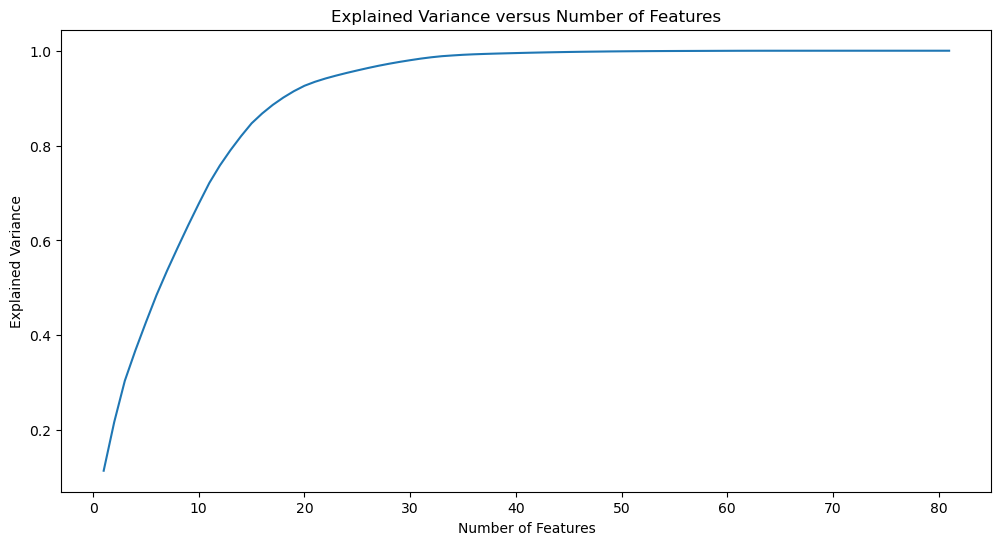

In [137]:
#Instantiate Principal Component Analysis.
pca=PCA()
X_pca = pca.fit_transform(X_trainres)
fig = plt.figure(figsize=(12,6))
plt.plot(range(1,X_trainres.shape[1]+1), pca.explained_variance_ratio_.cumsum())
plt.title('Explained Variance versus Number of Features')
plt.ylabel('Explained Variance')
plt.xlabel('Number of Features')
plt.show();

In [138]:
for n in [10,15,20,25]:
    pca_n = PCA(n_components=n)
    X_pcan = pca_n.fit_transform(X_trainres)
    tev = round(np.sum(pca_n.explained_variance_ratio_)*100,2)
    print('Number of Fetaures: ',n, 'Total Explained Variance: ',tev,'%')

Number of Fetaures:  10 Total Explained Variance:  67.74 %
Number of Fetaures:  15 Total Explained Variance:  84.7 %
Number of Fetaures:  20 Total Explained Variance:  92.61 %
Number of Fetaures:  25 Total Explained Variance:  95.85 %


From this graph I notice that the total explained variace starts to increase at a diminishing rate at around n_components=15. It also reduces dimensionality by a fourth of the size with just above 90% of the total variance explained. I would like the pipelines to try with n_components of 15,20,and 25.

## 5. Classification Models

Now that the data is prepped for modelling I will start by creating pipelines with grid search to tune the hyperparameters of each of the models. 

In [136]:
#Create pipeline for each of the classifiers.
#pipelines = {'logisticregression': Pipeline([('pca', PCA()),
                                            #('clf', LogisticRegression(random_state=123))]),
            #'decisiontree':Pipeline([('pca', PCA()),
                                            #('clf', DecisionTreeClassifier(random_state=123))]),
            #'randomforest':Pipeline([('pca', PCA()),
                                            #('clf', RandomForestClassifier(random_state=123))]),
            #'gradientboosting': Pipeline([('pca', PCA()),
                                           # ('clf', GradientBoostingClassifier(random_state=123))])}

#Define Hyperparameters for each pipeline
#hyperparameters_lr ={'pca__n_components': [15, 20, 25],
                     #'clf__C': [0.01,0.1,1]}

#hyperparameters_dt ={'pca__n_components': [10, 15, 20],
                    # 'clf__criterion': ['entropy', 'gini'], 
                    # 'clf__max_depth': [4, 5, 6],  
                    # 'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                    # 'clf__min_samples_split':[0.05 ,0.1, 0.2]}

#hyperparameters_rf ={'pca__n_components': [10, 15, 20],
                    # 'clf__n_estimators': [100,150],
                    # 'clf__criterion': ['entropy', 'gini'], 
                    # 'clf__max_depth': [4, 5, 6],  
                    # 'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                    # 'clf__min_samples_split':[0.05 ,0.1, 0.2]}

#hyperparameters_gb ={'pca__n_components': [10, 15, 20],
                    # 'clf__n_estimators': [100,150], 
                    # 'clf__max_depth': [1, 3, 5],  
                    # 'clf__learning_rate': [0.05,0.1]}

#Instantiate hyperparapeter dictionary
#hyperparameters = {'logisticregression':hyperparameters_lr ,
                   #'decisiontree':hyperparameters_dt,
                   #'randomforest':hyperparameters_rf,
                   #'gradientboosting': hyperparameters_gb}

In [ ]:
#model_scores_auc, fitted_models_auc = grid_pipe(pipelines,hyperparameters,scoring='roc_auc')

In [ ]:
#score_times_df_auc = pd.DataFrame(model_scores_auc,
                           #   columns=['classifier','roc_auc_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_auc

The best performing classifier is gradient boosting with almost 95% roc_auc score. It is expected that ensemble models perform better than single classifiers. However, this comes at greater computational cost. The second best performing model is also an ensemble model, random forest, but given it almost identical score to logistic regression and that it took close to 100 times more time to fit, I consider the second best model to be logistic regression.

In [128]:
#for name, model in fitted_models_auc.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
       # plot_confusion_matrix_from_data(y_test,pred, columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [129]:
#model_scores_f1, fitted_models_f1 = grid_pipe(pipelines,hyperparameters,scoring='f1')

In [135]:
#score_times_df_f1 = pd.DataFrame(model_scores_f1,
                             # columns=['classifier','f1_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_f1

In [134]:
#for name, model in fitted_models_f1.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
        #plot_confusion_matrix_from_data(y_test,pred,columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [133]:
#fitted_models_f1['gradientboosting'].best_params_

## 6. Conclusion and Recommendations
At first, I looked into the f1 score in order to improve the balnce of the imbalanced dataset. I checked for multicolinearity and delt with high correletaion features accordingly. The f1 score increase by about 6% and the roc_auc score by 8% just through scrubbing the data.

Once the data was ready to enter the pipelines to perform hyperparameter tuning, I conducted principal component analysis to derive the best n_component values to pass on to the pipelines. Turns out the with n_components =25 the data contains a little over 96% of the total explained variance, with half the number of total features. And, with n_components =15, the dataset contains over 90% of the total explained variance. So, decided to imput values in that range.

After running the grid search pipeline, the two best performing models are gradient boosting and logistic regression. Gradient boosting surpasses logistic regression in every metric, except running time. Hence, it will be important to consider the trade-off between computational cost and time.

In , my opinion, I recommend to test the Gradient Boosting Classifier in server conditions. If the model takes a long time to make the classiification, then Logistic Regression is preferred. Identification of the class of session as the user navigates the website has to be immediate in order to deploy marketing tactics that incentivize revenue generating behaviour being carefull not to be a deterrant. If the user is exhibiting favorable behaviour there is no need for aggresive tactics that could scare him.

In [131]:
#score_times_df_f1.loc[['gradientboosting','logisticregression']]

In [132]:
#score_times_df_auc.loc[['gradientboosting','logisticregression']]

## 7 Further Work
In order to keep improving the model, this are the following actionable steps:
+ Try a different SMOTE sampling startegy that resust in a different target incidency.
+ Create duartion per page for Administrative and Informative related pages.
+ Create a new pipeline with only logistic regressor and gradient boosting classifier and try other different parameters that approximate the pipe's resulting best parameters.

## 8. Bibliography and References
* Dataset: Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). https://link.springer.com/article/10.1007%2Fs00521-018-3523-0